In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import figurefirst as fifi
###

import sys
sys.path.insert(1, '../../../Code/')
from PlotUtilities import *
from FeatureFunctions import *
import matplotlib as mpl

plt.rcParams['font.serif'] = ['Times'] + plt.rcParams['font.serif']

plt.rcParams['text.usetex'] = False
plt.rcParams["ps.usedistiller"] = 'xpdf'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'normal'
plt.rcParams["mathtext.fontset"] = 'cm'


/home/flybot/anaconda3/envs/python3.11/lib/python3.11/site-packages/FlyPlotLib-0.0.1-py3.11.egg/fly_plot_lib/text.py:92: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/flybot/anaconda3/envs/python3.11/lib/python3.11/site-packages/FlyPlotLib-0.0.1-py3.11.egg/fly_plot_lib/text.py:94: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/flybot/anaconda3/envs/python3.11/lib/python3.11/site-packages/FlyPlotLib-0.0.1-py3.11.egg/fly_plot_lib/text.py:92: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/flybot/anaconda3/envs/python3.11/lib/python3.11/site-packages/FlyPlotLib-0.0.1-py3.11.egg/fly_plot_lib/text.py:94: SyntaxWarning: "is" with a literal. Did you mean "=="?
2025-04-15 09:50:00,367 [INFO] 
Limited Linear Model Support Detected! 
---> PYCHEBFUN is not installed. 
---> Install pychebfun to use chebfun derivatives (https://github.com/pychebfun/pychebfun/) 
You can still use other methods 



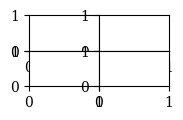

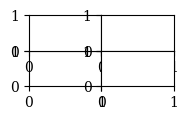

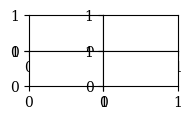

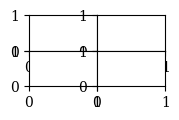

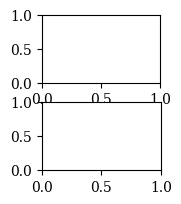

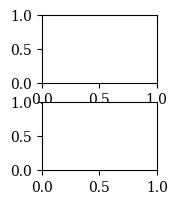

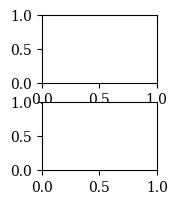

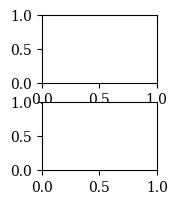

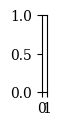

In [2]:
layout = fifi.svg_to_axes.FigureLayout('f4_trajectorycharacteristics.svg', autogenlayers=True, make_mplfigures=True, hide_layers=[])




# Bottom Half On

In [3]:
bottom_on_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/PreprocessedData/all_nights_new_processing_protocol_bottom_laminar_09092024.hdf')

In [4]:
bottom_on_df['ground speed'] = np.sqrt(bottom_on_df.xvel**2 + bottom_on_df.yvel**2)

In [5]:
df_flash_bottom_on = bottom_on_df[bottom_on_df.duration>0]
df_sham_bottom_on =bottom_on_df[bottom_on_df.duration==0]


In [6]:
flash_low_bottom_on = df_flash_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
flash_up_bottom_on  = df_flash_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

sham_low_bottom_on =df_sham_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
sham_up_bottom_on =df_sham_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

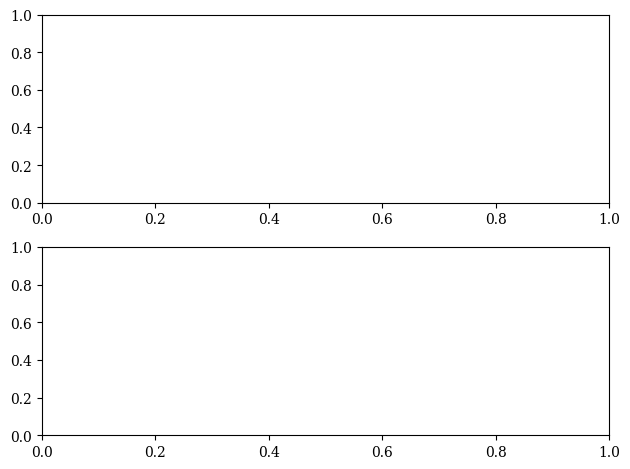

In [7]:
df1_left = flash_up_bottom_on# df_sham.groupby(['obj_id']).filter(lambda d: d[d['time stamp'].between(0,680)].z.mean()>.25 )
df1_left = df1_left.groupby("obj_id_unique").filter(lambda d: np.any(d.duplicate_obj_id_bool)==False)
n_flash = len(df1_left.obj_id_unique.unique())
fig, ax = plt.subplots( ncols=1,nrows=2,layout='tight')
cmap_reversed = plt.colormaps.get_cmap('bone_r')

ax[0] = layout.axes[('C1', 'c1')]
ax[1] = layout.axes[('C1', 'c2')]


a = np.arange(-.500,3.000,.010)
b = np.linspace(-np.pi, np.pi, 180)
y= np.linspace(-np.pi, np.pi, 181)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d( df1_left['time stamp']/1000,df1_left['heading'], bins =(x,y), density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[0].pcolormesh(X,Y, newdf_normed,vmin=0, vmax=0.04,cmap='bone_r', shading='flat', rasterized=True)


df1_left = sham_up_bottom_on
df1_left = df1_left.groupby("obj_id_unique").filter(lambda d: np.any(d.duplicate_obj_id_bool)==False)
sham_ids = df1_left[df1_left['time stamp']==0].groupby('obj_id_unique').filter(lambda d: (d['x'].between(-.35,0.35)) & (d['y'].between(-0.1,0.1)) & (d['z'].between(0.05,0.35))).obj_id_unique
df1_left = df1_left [df1_left.obj_id_unique.isin(list(sham_ids))]

a = np.arange(-.5,3,.010)
b = np.linspace(-np.pi, np.pi, 180)
y= np.linspace(-np.pi, np.pi, 181)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d(df1_left['time stamp']/1000,df1_left['heading'],  bins =(x, y),density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[1].pcolormesh(X, Y, newdf_normed,  vmin=0,vmax=0.04,cmap='bone_r', shading='flat', rasterized=True,)


fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[-np.pi, -np.pi/2, 0, np.pi/2, np.pi],  xticks=[-.5, 0, .68, 3],spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)
ax[0].set_xticklabels(['', '', '', ''])
fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-np.pi, -np.pi/2, 0, np.pi/2, np.pi],  xticks=[-.5, 0, .68, 3], spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)
ax[0].set_yticklabels(['', '', '','',''])
ax[1].set_yticklabels(['', '', '','',''])
ax[1].set_xticklabels(['', '', '', ''])

ax[0].set_aspect(0.3)
ax[1].set_aspect(0.3)

fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)


ax[0].text(x=3,y=3.14, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(n_flash), fontsize=5,fontstyle='italic',rotation=90, bbox=dict(facecolor='white', edgecolor='white', pad=0.05,alpha=0.7))
ax[1].text(x=3,y=3.14, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(len(df1_left.obj_id_unique.unique())), fontsize=5, rotation=90,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7))

ax[0].axvspan(0, .675, color = 'red', edgecolor=None, alpha = 0.1)
ax[1].axvspan(0, .675, color = 'grey', edgecolor=None, alpha = 0.2) 


layout.append_figure_to_layer(layout.figures['C1'], 'C1', cleartarget=True)



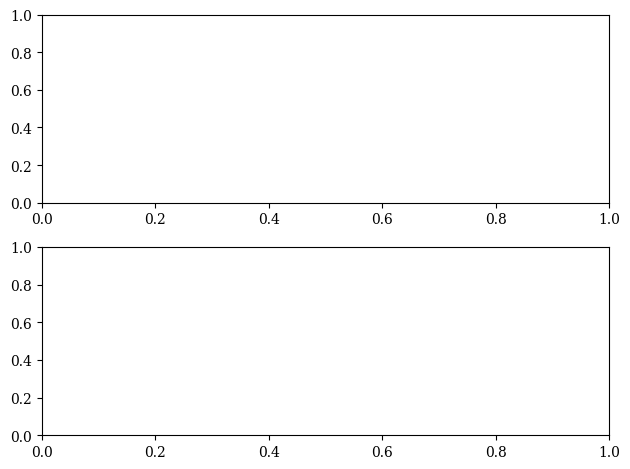

In [8]:
df1_left = flash_low_bottom_on# df_sham.groupby(['obj_id']).filter(lambda d: d[d['time stamp'].between(0,680)].z.mean()>.25 )

df1_left = df1_left.groupby("obj_id_unique").filter(lambda d: np.any(d.duplicate_obj_id_bool)==False)
n_flash = len(df1_left.obj_id_unique.unique())
fig, ax = plt.subplots( ncols=1,nrows=2,layout='tight')
cmap_reversed = plt.colormaps.get_cmap('bone_r')
ax[0] = layout.axes[('A1', 'a1')]
ax[1] = layout.axes[('A1', 'a2')]


a = np.arange(-.500,3.000,.010)
b = np.linspace(-np.pi, np.pi, 180)
y= np.linspace(-np.pi, np.pi, 181)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d( df1_left['time stamp']/1000,df1_left['heading'], bins =(x,y),density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[0].pcolormesh(X,Y, newdf_normed, vmin=0, vmax=0.04, cmap='bone_r', shading='flat', rasterized=True)





df1_left = sham_low_bottom_on
df1_left = df1_left.groupby("obj_id_unique").filter(lambda d: np.any(d.duplicate_obj_id_bool)==False)
sham_ids = df1_left[df1_left['time stamp']==0].groupby('obj_id_unique').filter(lambda d: (d['x'].between(-.35,0.35)) & (d['y'].between(-0.1,0.1)) & (d['z'].between(0.05,0.35))).obj_id_unique
df1_left = df1_left [df1_left.obj_id_unique.isin(list(sham_ids))]


a = np.arange(-.5,3,.010)
b = np.linspace(-np.pi, np.pi, 180)
y= np.linspace(-np.pi, np.pi, 181)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d(df1_left['time stamp']/1000,df1_left['heading'],  bins =(x, y),density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.04, cmap='bone_r', shading='flat', rasterized=True,)



fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-np.pi,-np.pi/2,0,np.pi/2, np.pi], xticks=[-0.5, 0, 0.68, 3],spine_locations={'left':5, 'bottom':5},   tick_length=3, linewidth=.5)
fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[-np.pi,-np.pi/2,0,np.pi/2, np.pi], xticks=[-0.5, 0, 0.68, 3], spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)

ax[0].set_aspect(.3) 
ax[1].set_aspect(.3)

ax[0].axvspan(0, .675, color = 'red', edgecolor=None, alpha = 0.1)
ax[1].axvspan(0, .675, color = 'grey', edgecolor=None, alpha = 0.2) 


yticklabels = [r'-$\pi$', r'-$\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$']
ax[0].set_xticklabels(['','','',''])
ax[0].set_yticklabels(yticklabels)
ax[1].set_yticklabels(yticklabels)
ax[1].set_xticklabels(['-0.5','0','0.68','3'])
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Course Direction', labelpad=0)
ax[0].set_ylabel('Course Direction', labelpad=0)


fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)

ax[0].text(x=3,y=3.14, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(n_flash), fontsize=5,fontstyle='italic',rotation=90, bbox=dict(facecolor='white', edgecolor='white', pad=0.05,alpha=0.7))
ax[1].text(x=3,y=3.14, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(len(df1_left.obj_id_unique.unique())), fontsize=5, rotation=90,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7))



layout.append_figure_to_layer(layout.figures['A1'], 'A1', cleartarget=True)



# Top Half On

In [9]:
top_on_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/PreprocessedData/all_nights_new_processing_protocol_top_laminar_09092024.hdf')

In [10]:
top_on_df['ground speed'] = np.sqrt(top_on_df.xvel**2 + top_on_df.yvel**2)

In [11]:
df_flash_top_on = top_on_df[top_on_df.duration>0]
df_sham_top_on =top_on_df[top_on_df.duration==0]

In [12]:
flash_low_top_on = df_flash_top_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
flash_up_top_on  = df_flash_top_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)


sham_low_top_on =df_sham_top_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
sham_up_top_on =df_sham_top_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

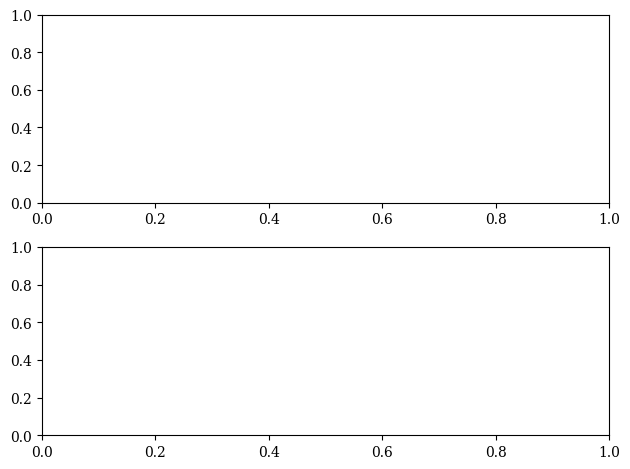

In [13]:
df1_left = flash_up_top_on# df_sham.groupby(['obj_id']).filter(lambda d: d[d['time stamp'].between(0,680)].z.mean()>.25 )

df1_left = df1_left.groupby("obj_id_unique").filter(lambda d: np.any(d.duplicate_obj_id_bool)==False)
n_flash = len(df1_left.obj_id_unique.unique())

fig, ax = plt.subplots( ncols=1,nrows=2,layout='tight')
cmap_reversed = plt.colormaps.get_cmap('bone_r')
ax[0] = layout.axes[('B1', 'b1')]
ax[1] = layout.axes[('B1', 'b2')]


a = np.arange(-.500,3.000,.010)
b = np.linspace(-np.pi, np.pi, 180)
y= np.linspace(-np.pi, np.pi, 181)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d( df1_left['time stamp']/1000,df1_left['heading'], bins =(x,y), density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[0].pcolormesh(X,Y, newdf_normed, vmin=0, vmax=0.04,cmap='bone_r', shading='flat', rasterized=True)



df1_left = sham_up_top_on# df_sham.groupby(['obj_id']).filter(lambda d: d[d['time stamp'].between(0,680)].z.mean()>.25 )
df1_left = df1_left.groupby("obj_id_unique").filter(lambda d: np.any(d.duplicate_obj_id_bool)==False)
sham_ids = df1_left[df1_left['time stamp']==0].groupby('obj_id_unique').filter(lambda d: (d['x'].between(-.35,0.35)) & (d['y'].between(-0.1,0.1)) & (d['z'].between(0.05,0.4))).obj_id_unique
df1_left = df1_left [df1_left.obj_id_unique.isin(list(sham_ids))]

a = np.arange(-.5,3,.010)
b = np.linspace(-np.pi, np.pi, 180)
y= np.linspace(-np.pi, np.pi, 181)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d(df1_left['time stamp']/1000,df1_left['heading'],  bins =(x, y), density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[1].pcolormesh(X, Y, newdf_normed,vmin=0, vmax=0.04, cmap='bone_r', shading='flat', rasterized=True,)

fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[-np.pi, -np.pi/2, 0, np.pi/2, np.pi],  xticks=[-.5, 0, .68, 3],spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)
ax[0].set_xticklabels(['', '', '', ''])

fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-np.pi, -np.pi/2, 0, np.pi/2, np.pi],  xticks=[-.5, 0, .68, 3], spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)
ax[0].set_yticklabels(['', '', '','',''])
ax[1].set_yticklabels(['', '', '','',''])
ax[1].set_xticklabels(['', '', '', ''])

ax[0].axvspan(0, .675, color = 'red', edgecolor=None, alpha = 0.1)
ax[1].axvspan(0, .675, color = 'grey', edgecolor=None, alpha = 0.2) 

fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)

ax[0].set_aspect(.3) 
ax[1].set_aspect(.3)


ax[0].text(x=3,y=3.14, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(n_flash), fontsize=5,fontstyle='italic',rotation=90, bbox=dict(facecolor='white', edgecolor='white', pad=0.05,alpha=0.7))
ax[1].text(x=3,y=3.14, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(len(df1_left.obj_id_unique.unique())), fontsize=5, rotation=90,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7))

layout.append_figure_to_layer(layout.figures['B1'], 'B1', cleartarget=True)


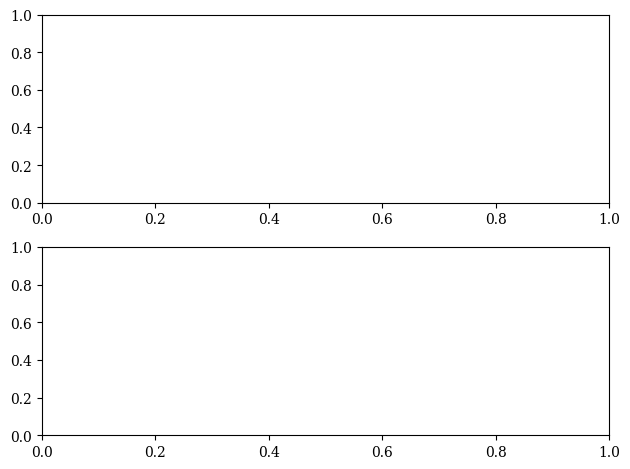

In [14]:

fig, ax = plt.subplots( ncols=1,nrows=2,layout='tight')
cmap_reversed = plt.colormaps.get_cmap('bone_r')
ax[0] = layout.axes[('D1', 'd1')]
ax[1] = layout.axes[('D1', 'd2')]

df1_left = flash_low_top_on
df1_left = df1_left.groupby("obj_id_unique").filter(lambda d: np.any(d.duplicate_obj_id_bool)==False)
n_flash = len(df1_left.obj_id_unique.unique())
a = np.arange(-.500,3.000,.010)
b = np.linspace(-np.pi, np.pi, 180)
y= np.linspace(-np.pi, np.pi, 181)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d( df1_left['time stamp']/1000,df1_left['heading'], bins =(x,y),density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[0].pcolormesh(X,Y, newdf_normed, vmin=0,vmax=0.04,  cmap='bone_r', shading='flat', rasterized=True) #vmin=0, vmax=0.035,

#######################################################################
df1_left = sham_low_top_on
df1_left = df1_left.groupby("obj_id_unique").filter(lambda d: np.any(d.duplicate_obj_id_bool)==False)
sham_ids = df1_left[df1_left['time stamp']==0].groupby('obj_id_unique').filter(lambda d: (d['x'].between(-.35,0.35)) & (d['y'].between(-0.1,0.1)) & (d['z'].between(0.05,0.4))).obj_id_unique
df1_left = df1_left [df1_left.obj_id_unique.isin(list(sham_ids))]
a = np.arange(-.5,3,.010)
b = np.linspace(-np.pi, np.pi, 180)
y= np.linspace(-np.pi, np.pi, 181)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d(df1_left['time stamp']/1000,df1_left['heading'],  bins =(x, y),density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.04, cmap='bone_r', shading='flat', rasterized=True,) #vmin=0,vmax=0.035,




ax[0].set_aspect(.3) 
ax[1].set_aspect(.3)


fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[-np.pi, -np.pi/2, 0, np.pi/2, np.pi],  xticks=[-.5, 0, .68, 3],spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)
ax[0].set_xticklabels(['', '', '', ''])
fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-np.pi, -np.pi/2, 0, np.pi/2, np.pi],  xticks=[-.5, 0, .68, 3], spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)
ax[0].set_yticklabels(['', '', '','',''])
ax[1].set_yticklabels(['', '', '','',''])
ax[1].set_xticklabels(['', '', '', ''])
    
ax[0].axvspan(0, .675, color = 'red', edgecolor=None, alpha = 0.1)
ax[1].axvspan(0, .675, color = 'grey', edgecolor=None, alpha = 0.2) 

fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)


ax[0].text(x=3,y=3.14, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(n_flash), fontsize=5,fontstyle='italic',rotation=90, bbox=dict(facecolor='white', edgecolor='white', pad=0.05,alpha=0.7))
ax[1].text(x=3,y=3.14, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(len(df1_left.obj_id_unique.unique())), fontsize=5, rotation=90,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7))

layout.append_figure_to_layer(layout.figures['D1'], 'D1', cleartarget=True)



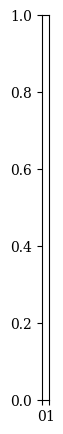

In [15]:

fig, ax = plt.subplots(figsize=(.1,5))
ax = layout.axes[('CB', 'cb')] 




sm = mpl.cm.ScalarMappable(cmap='bone_r', norm=mpl.colors.Normalize(vmin=0, vmax=0.04)) 
fig.colorbar(sm, cax=ax,  orientation='vertical')
fifi.mpl_functions.adjust_spines(ax, ['right'], yticks=[0,0.05], spine_locations={'right':1}, tick_length=1, linewidth=0.5)
ax.set_yticklabels(['0','0.04'])

fifi.mpl_functions.set_fontsize(ax, 6)
ax.set_aspect(500)

layout.append_figure_to_layer(layout.figures['CB'], 'CB', cleartarget=True)




## Trajectory Example plots

In [15]:
### traj ids for individual examples ###

# steady
## flash_low_bottom_on: '3661_20240113_171950', '22174_20240113_171950', '8150_20240516_185822', '7224_20240516_185822', '11235_20240516_185822, '11008_2024516_185822'
## flash_up_top_on: '3155_20240109_173223', '13465_20240109_173223', '4598_20240515_182700', '3856_20240111_160822'

# unsteady
## flash_up_bottom_on: '14439_20240113_171950', '11875_20240113_171950', '7208_20240113_171950', '3971_20240114_171954'
## flash_low_top_on: '10591_20240514_172126', '8827_20240513_181409', '8870_20240513_181409', '8802_20240514_172126', '11411_20240110_164820', '3821_20240515_182700', 


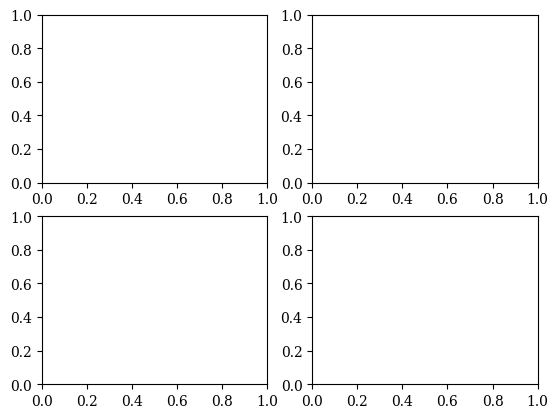

In [16]:
## flash_low_bottom_on: 

trajs=['3661_20240113_171950', '22174_20240113_171950', '8150_20240516_185822', '7224_20240516_185822', '11235_20240516_185822', '11008_2024516_185822']

fig, ax= plt.subplots(nrows=2,ncols=2)
ax[0,0] = layout.axes[('A_t', 't1_a')]
ax[0,1] = layout.axes[('A_t', 't2_a')]
ax[1,0] = layout.axes[('A_t', 't3_a')]
ax[1,1] = layout.axes[('A_t', 't4_a')]

for i, subplot in enumerate([ax[0,0], ax[0,1], ax[1,0], ax[1,1]]):
    get_subplot(flash_low_bottom_on, trajs[i], ax=subplot)


layout.append_figure_to_layer(layout.figures['A_t'], 'A_t', cleartarget=True)


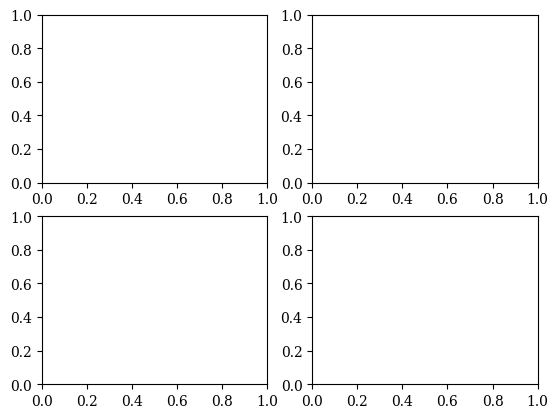

In [17]:

## flash_up_top_on: 
trajs=['3155_20240109_173223', '13465_20240109_173223', '4598_20240515_182700', '3856_20240111_160822']
fig, ax= plt.subplots(nrows=2,ncols=2)
ax[0,0] = layout.axes[('B_t', 't1_b')]
ax[0,1] = layout.axes[('B_t', 't2_b')]
ax[1,0] = layout.axes[('B_t', 't3_b')]
ax[1,1] = layout.axes[('B_t', 't4_b')]

for i, subplot in enumerate([ax[0,0], ax[0,1], ax[1,0], ax[1,1]]):
    get_subplot(flash_up_top_on, trajs[i], ax=subplot)


layout.append_figure_to_layer(layout.figures['B_t'], 'B_t', cleartarget=True)


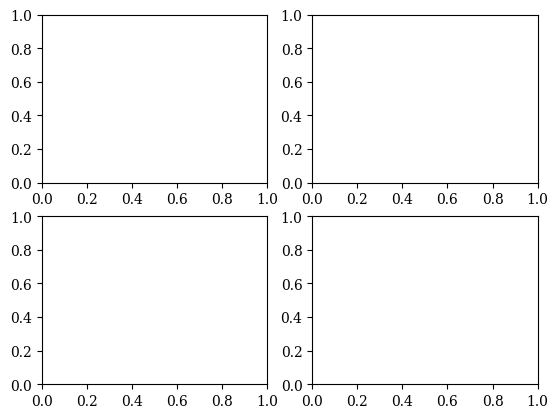

In [18]:
## flash_up_bottom_on: 

trajs=['14439_20240113_171950', '11875_20240113_171950', '7208_20240113_171950', '3971_20240114_171954']
fig, ax= plt.subplots(nrows=2,ncols=2)
ax[0,0] = layout.axes[('C_t', 't1_c')]
ax[0,1] = layout.axes[('C_t', 't2_c')]
ax[1,0] = layout.axes[('C_t', 't3_c')]
ax[1,1] = layout.axes[('C_t', 't4_c')]

for i, subplot in enumerate([ax[0,0], ax[0,1], ax[1,0], ax[1,1]]):
    get_subplot(flash_up_bottom_on, trajs[i], ax=subplot)


layout.append_figure_to_layer(layout.figures['C_t'], 'C_t', cleartarget=True)


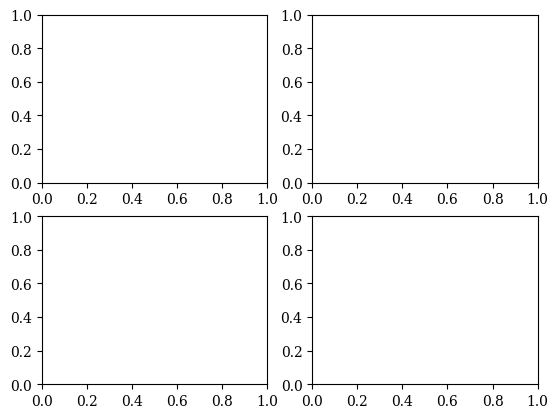

In [19]:
## flash_low_top_on: 

trajs=['10591_20240514_172126', '8827_20240513_181409', '8870_20240513_181409', '8802_20240514_172126', '11411_20240110_164820', '3821_20240515_182700',] 
fig, ax= plt.subplots(nrows=2,ncols=2)
ax[0,0] = layout.axes[('D_t', 't1_d')]
ax[0,1] = layout.axes[('D_t', 't2_d')]
ax[1,0] = layout.axes[('D_t', 't3_d')]
ax[1,1] = layout.axes[('D_t', 't4_d')]

for i, subplot in enumerate([ax[0,0], ax[0,1], ax[1,0], ax[1,1]]):
    get_subplot(flash_low_top_on, trajs[i], ax=subplot)


layout.append_figure_to_layer(layout.figures['D_t'], 'D_t', cleartarget=True)


In [84]:
layout.write_svg('f4_trajectorycharacteristics.svg')